# RQ1: what drives adoption

A logistic model on the pooled Findex data, with a driver ranking. I code it by hand with numpy so the notebook runs without any heavy libraries.

## Setup (local or Google Colab)

On Colab this pulls the project data and code from GitHub. Locally it uses the repo folder you already have.

In [1]:
# Works whether you run this locally or on Google Colab.
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not os.path.isdir('data'):
    import subprocess
    subprocess.run(['git','clone','-q','https://github.com/bcudjoe/mobile-money-ghana-forecasting.git'])
    os.chdir('mobile-money-ghana-forecasting')
print('Colab' if IN_COLAB else 'local')

local


In [2]:
import pandas as pd, numpy as np, os, matplotlib
import matplotlib.pyplot as plt
FIG='outputs/figures/'; os.makedirs(FIG, exist_ok=True)
NAVY='#1F3864'; GRN='#1E7A46'; ORA='#E08A1E'
fx=pd.read_csv('data/processed/findex_ghana_clean.csv')
rng=np.random.default_rng(42)

## Set up the features and split the data

In [3]:
feats=['has_account','made_digital_payment','income_quintile','education','age','female','urban','owns_mobile','has_internet','employed','borrowed_formal','saved_formal']
fx['wave2025']=(fx['wave']==2025).astype(int); feats=feats+['wave2025']
X=fx[feats].astype(float).values; y=fx['adopts_mm'].astype(float).values
mu=X.mean(0); sd=X.std(0); sd[sd==0]=1; Xz=(X-mu)/sd
# 70/30 train-test split
idx=rng.permutation(len(y)); cut=int(.7*len(y)); tr,te=idx[:cut], idx[cut:]
Xtr=np.c_[np.ones(len(tr)),Xz[tr]]; Xte=np.c_[np.ones(len(te)),Xz[te]]; ytr,yte=y[tr],y[te]

## Fit the logistic regression

Plain gradient descent on the standardised features.

In [4]:
w=np.zeros(Xtr.shape[1]); lr=0.3
for _ in range(4000):
    p=1/(1+np.exp(-Xtr@w)); w-=lr*Xtr.T@(p-ytr)/len(ytr)
pte=1/(1+np.exp(-Xte@w)); pred=(pte>=.5).astype(int)

## Metrics on the held-out respondents

In [5]:
TP=int(((pred==1)&(yte==1)).sum()); TN=int(((pred==0)&(yte==0)).sum())
FP=int(((pred==1)&(yte==0)).sum()); FN=int(((pred==0)&(yte==1)).sum())
acc=(TP+TN)/len(yte); prec=TP/(TP+FP); rec=TP/(TP+FN); f1=2*prec*rec/(prec+rec)
pos=pte[yte==1]; neg=pte[yte==0]
auc=((pos[:,None]>neg[None,:]).sum()+0.5*(pos[:,None]==neg[None,:]).sum())/(len(pos)*len(neg))
print(f'accuracy={acc:.3f} precision={prec:.3f} recall={rec:.3f} f1={f1:.3f} auc={auc:.3f}')
print('confusion TP,TN,FP,FN =', TP,TN,FP,FN)

accuracy=0.978 precision=0.972 recall=1.000 f1=0.986 auc=0.970
confusion TP,TN,FP,FN = 452 135 13 0


## Figure 6: ROC curve

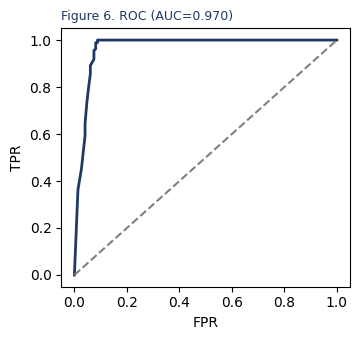

In [6]:
th=np.linspace(0,1,101); tpr=[]; fpr=[]
for t in th:
    pr=(pte>=t).astype(int)
    tp=((pr==1)&(yte==1)).sum(); fn=((pr==0)&(yte==1)).sum(); fp=((pr==1)&(yte==0)).sum(); tn=((pr==0)&(yte==0)).sum()
    tpr.append(tp/(tp+fn) if tp+fn else 0); fpr.append(fp/(fp+tn) if fp+tn else 0)
plt.figure(figsize=(3.7,3.5)); plt.plot(fpr,tpr,color=NAVY,lw=2); plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'Figure 6. ROC (AUC={auc:.3f})', loc='left', color=NAVY, fontsize=9)
plt.tight_layout(); plt.savefig(FIG+'fig6_roc.png'); plt.show()

## Figure 7: which features matter most

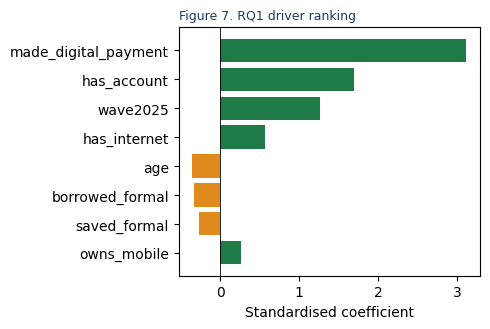

Top drivers: [('made_digital_payment', np.float64(3.115)), ('has_account', np.float64(1.696)), ('wave2025', np.float64(1.268)), ('has_internet', np.float64(0.569)), ('age', np.float64(-0.352)), ('borrowed_formal', np.float64(-0.331)), ('saved_formal', np.float64(-0.268)), ('owns_mobile', np.float64(0.258))]


In [7]:
imp=sorted(zip(feats,w[1:]), key=lambda t:-abs(t[1]))[:8]
names=[k for k,_ in imp][::-1]; vals=[v for _,v in imp][::-1]
plt.figure(figsize=(5,3.4)); plt.barh(names, vals, color=[GRN if v>0 else ORA for v in vals]); plt.axvline(0,color='k',lw=.6)
plt.xlabel('Standardised coefficient'); plt.title('Figure 7. RQ1 driver ranking', loc='left', color=NAVY, fontsize=9)
plt.tight_layout(); plt.savefig(FIG+'fig7_drivers.png'); plt.show()
print('Top drivers:', [(k, round(v,3)) for k,v in imp])

One thing to keep in mind: two of the strongest predictors here, `made_digital_payment` and `has_account`, basically overlap with using mobile money, so they push the accuracy up. For the final version I will re-run the model without them to get a fairer picture of the social and economic drivers.